In [9]:
import scion
import ENDFtk

In [ ]:
# ENDF/B-VI.8 data for Cm244
cm244_endf68 = ENDFtk.tree.Tape.from_file( '/Users/wim/Projects/libraries/endf/endf68/neutrons/n-96244.endf' )

data_endf68 = scion.from_endf( cm244_endf68.materials.front().file(1).section(452).parse() )

# the nubar data is given as a polynomial series
print( data_endf68 )
print( data_endf68.coefficients )

# linearise the data
data_endf68 = data_endf68.linearise()

# the nubar data is now a lin-lin table
print( data_endf68 )
print( data_endf68.x )
print( data_endf68.y )

In [ ]:
# ENDF/B-VIII.0 data for Cm244
cm244_endf80 = ENDFtk.tree.Tape.from_file( '/Users/wim/Projects/libraries/endf/endf80/neutrons/n-096_Cm_244.endf' )

data_endf80 = scion.from_endf( cm244_endf80.materials.front().file(1).section(452).parse() )

# the nubar data is a lin-lin table
print( data_endf80 )
print( data_endf80.x )
print( data_endf80.y )

In [ ]:
import matplotlib.pyplot as plot

# plot the data
plot.figure()
plot.plot( data_endf68.x, data_endf68.y, label = '${}^{244}$Cm nubar ENDF/B-VI.8', color = 'red', linewidth = 1.0 )
plot.plot( data_endf80.x, data_endf80.y, label = '${}^{244}$Cm nubar ENDF/B-VIII.0', color = 'blue', linewidth = 1.0 )
plot.xlabel( 'Energy (eV)' )
plot.ylabel( 'Neutrons per fission' )
plot.title( 'ENDF/B-VI.8 versus ENDF/B-VIII.0' )
plot.xlim( 1e-5, 10e+6 )
plot.xscale( 'log' )
plot.yscale( 'linear' )
plot.legend()
plot.show()

In [61]:
import scion
import ENDFtk

# convert to the proper Legendre coefficients
def convert( data, index ) :
    
    coefficients = data.angular_distributions[index].coefficients
    converted = [ 0.5 ]
    for i in range( 1, len( coefficients ) + 1 ) :
        
        converted.append( ( 2 * i + 1 ) / 2 * coefficients[i - 1] )
    
    return converted

# open the U235 data and extract the elastic angular distribution data for neutrons
u235 = ENDFtk.tree.Tape.from_file( 'h1.endf' )
elastic = u235.materials.front().file( 4 ).section( 2 ).parse()

# retrieve the angular distributions at different energies
distribution1 = scion.math.LegendreSeries( convert( elastic, 0 ) )
distribution2 = scion.math.LegendreSeries( convert( elastic, -11 ) )
distribution3 = scion.math.LegendreSeries( convert( elastic, -1 ) )


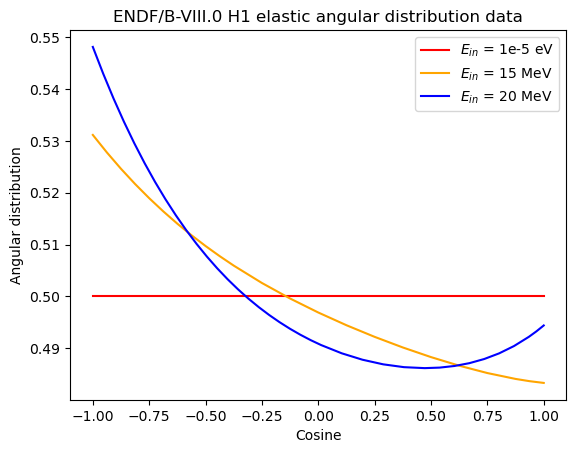

In [63]:
import matplotlib.pyplot as plot

tolerance = scion.linearisation.ToleranceConvergence( .0001 )
plot1 = distribution1.linearise(tolerance)
plot2 = distribution2.linearise(tolerance)
plot3 = distribution3.linearise(tolerance)

# plot the data
plot.figure()
plot.plot( plot1.x, plot1.y, label = '$E_{in}$ = 1e-5 eV', color = 'red', linewidth = 1.5 )
plot.plot( plot2.x, plot2.y, label = '$E_{in}$ = 15 MeV', color = 'orange', linewidth = 1.5 )
plot.plot( plot3.x, plot3.y, label = '$E_{in}$ = 20 MeV', color = 'blue', linewidth = 1.5 )
plot.xlabel( 'Cosine' )
plot.ylabel( 'Angular distribution' )
plot.title( 'ENDF/B-VIII.0 H1 elastic angular distribution data' )
plot.legend()
plot.show()